In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

# Load dataset
df = pd.read_csv("Kelas G_Fixed Call Report.csv")
df.columns = df.columns.str.strip()
df.rename(columns={df.columns[0]: "Year"}, inplace=True)

# Konversi tipe data
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Total Number of Calls"] = pd.to_numeric(df["Total Number of Calls"], errors="coerce")
df["Number of Total Complaints"] = pd.to_numeric(df["Number of Total Complaints"], errors="coerce")
df["Total Number of Doctors Consultancy"] = pd.to_numeric(df["Total Number of Doctors Consultancy"], errors="coerce")

# Urutan bulan
month_order = ["Jan","Feb","Mar","Apr","May","June","July","Aug","Sept","Oct","Nov","Dec"]
df["Month"] = pd.Categorical(df["Month"], categories=month_order, ordered=True)

df.head()

,Year,Month,Total Number of Calls,Total Number of Doctors Consultancy,Number of Total Health Information,Number of Total Ambulance Information,Number of Total Complaints,Number of Calls To Know About The Service
0,2025,Feb,155200,98964,3777,5773,3706,42980
1,2025,Jan,130982,87815,3217,4179,3178,32593
2,2024,Dec,133725,86832,3634,3735,3035,36489
3,2024,Nov,153698,93710,3010,4421,4133,48424
4,2024,Oct,214604,108207,6307,5792,8885,80804


## Grafik 1 – Kategori A: Agregasi
Total keseluruhan jumlah panggilan berdasarkan tahun (Bar Chart)

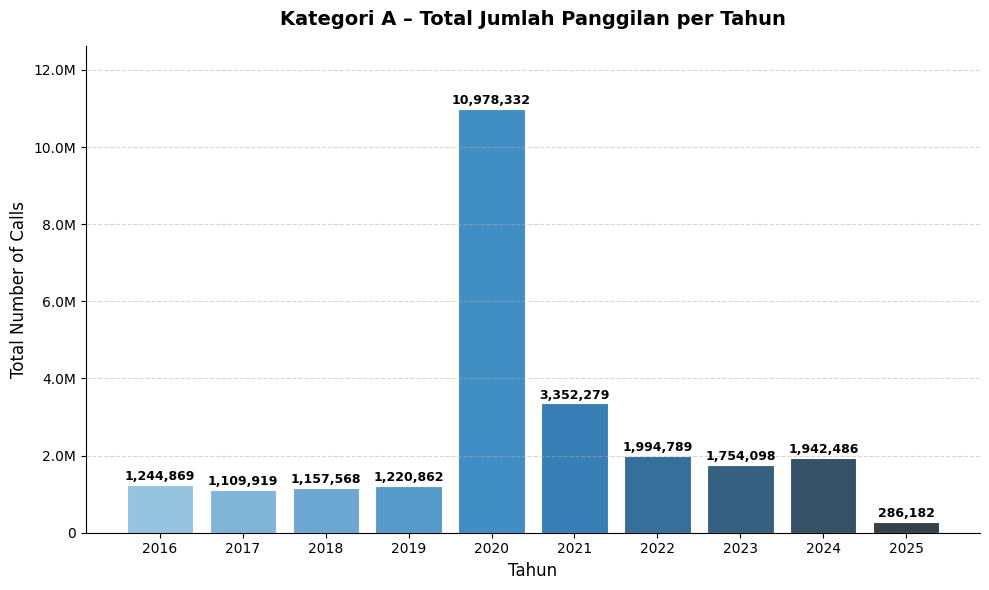

In [7]:
agg_year = df.groupby("Year")["Total Number of Calls"].sum().reset_index()
agg_year = agg_year.sort_values("Year")

fig1, ax1 = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("Blues_d", len(agg_year))
bars = ax1.bar(agg_year["Year"].astype(str), agg_year["Total Number of Calls"],
               color=colors, edgecolor="white", linewidth=0.8)

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 50000,
             f"{height:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax1.set_title("Kategori A – Total Jumlah Panggilan per Tahun", fontsize=14, fontweight="bold", pad=15)
ax1.set_xlabel("Tahun", fontsize=12)
ax1.set_ylabel("Total Number of Calls", fontsize=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x:,.0f}"))
ax1.set_ylim(0, agg_year["Total Number of Calls"].max() * 1.15)
ax1.grid(axis="y", linestyle="--", alpha=0.5)
sns.despine(ax=ax1, top=True, right=True)
plt.tight_layout()
plt.show()

## Grafik 2 – Kategori B: Tren/Filter
Tren bulanan komplain/keluhan pada tahun 2024 (Line Chart)

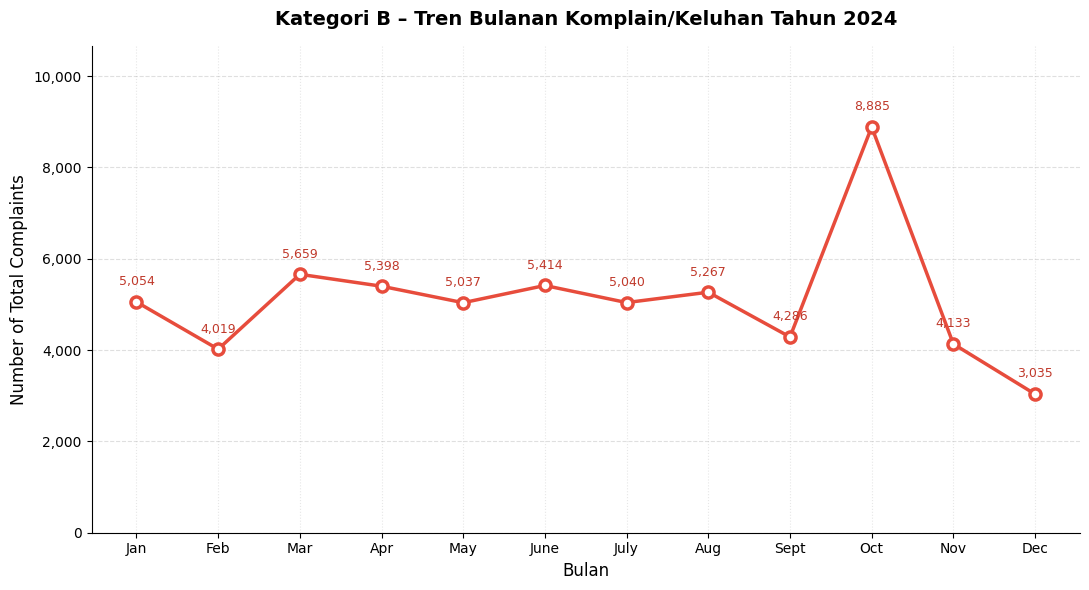

In [8]:
df_2024 = df[df["Year"] == 2024].sort_values("Month")

fig2, ax2 = plt.subplots(figsize=(11, 6))
ax2.plot(df_2024["Month"].astype(str), df_2024["Number of Total Complaints"],
         marker="o", color="#e74c3c", linewidth=2.5, markersize=8,
         markerfacecolor="white", markeredgewidth=2.5)

for _, row in df_2024.iterrows():
    ax2.annotate(f"{row['Number of Total Complaints']:,}",
                 xy=(row["Month"], row["Number of Total Complaints"]),
                 xytext=(0, 12), textcoords="offset points",
                 ha="center", fontsize=9, color="#c0392b")

ax2.set_title("Kategori B – Tren Bulanan Komplain/Keluhan Tahun 2024", fontsize=14, fontweight="bold", pad=15)
ax2.set_xlabel("Bulan", fontsize=12)
ax2.set_ylabel("Number of Total Complaints", fontsize=12)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax2.set_ylim(0, df_2024["Number of Total Complaints"].max() * 1.20)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.grid(axis="x", linestyle=":", alpha=0.3)
sns.despine(ax=ax2, top=True, right=True)
plt.tight_layout()
plt.show()

## Grafik 3 – Kategori C: Korelasi
Hubungan antara konsultasi dokter dan total volume panggilan masuk (Scatter Plot)

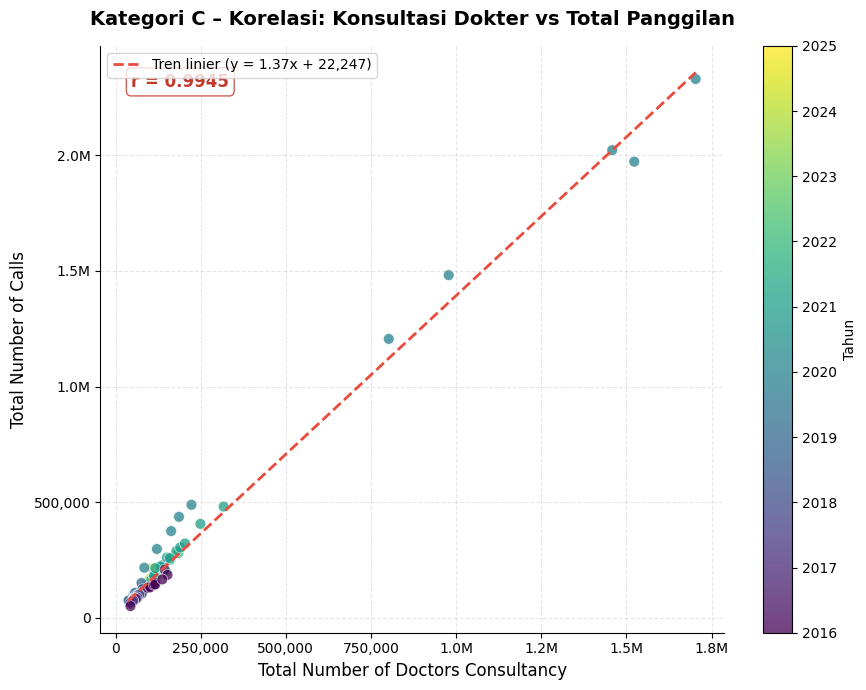

In [9]:
fig3, ax3 = plt.subplots(figsize=(9, 7))
scatter = ax3.scatter(df["Total Number of Doctors Consultancy"],
                      df["Total Number of Calls"],
                      c=df["Year"], cmap="viridis", s=60, alpha=0.75,
                      edgecolor="white", linewidth=0.5)

x = df["Total Number of Doctors Consultancy"].dropna()
y = df.loc[x.index, "Total Number of Calls"]
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
ax3.plot(x_line, m * x_line + b, color="#e74c3c", linewidth=2,
         linestyle="--", label=f"Tren linier (y = {m:.2f}x + {b:,.0f})")

r = x.corr(y)
ax3.text(0.05, 0.93, f"r = {r:.4f}", transform=ax3.transAxes,
         fontsize=12, color="#c0392b", fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#c0392b", alpha=0.8))

cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label("Tahun", fontsize=10)
ax3.legend(fontsize=10, loc="upper left")
ax3.set_title("Kategori C – Korelasi: Konsultasi Dokter vs Total Panggilan", fontsize=14, fontweight="bold", pad=15)
ax3.set_xlabel("Total Number of Doctors Consultancy", fontsize=12)
ax3.set_ylabel("Total Number of Calls", fontsize=12)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x:,.0f}"))
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x:,.0f}"))
ax3.grid(linestyle="--", alpha=0.3)
sns.despine(ax=ax3, top=True, right=True)
plt.tight_layout()
plt.show()

## Grafik 4 – Kategori D: Distribusi
Identifikasi outlier atas pada jumlah komplain bulanan (Boxplot)

Q1 = 697 | Q3 = 8,262 | IQR = 7,565
Upper Fence = 19,610
Jumlah bulan outlier atas: 10


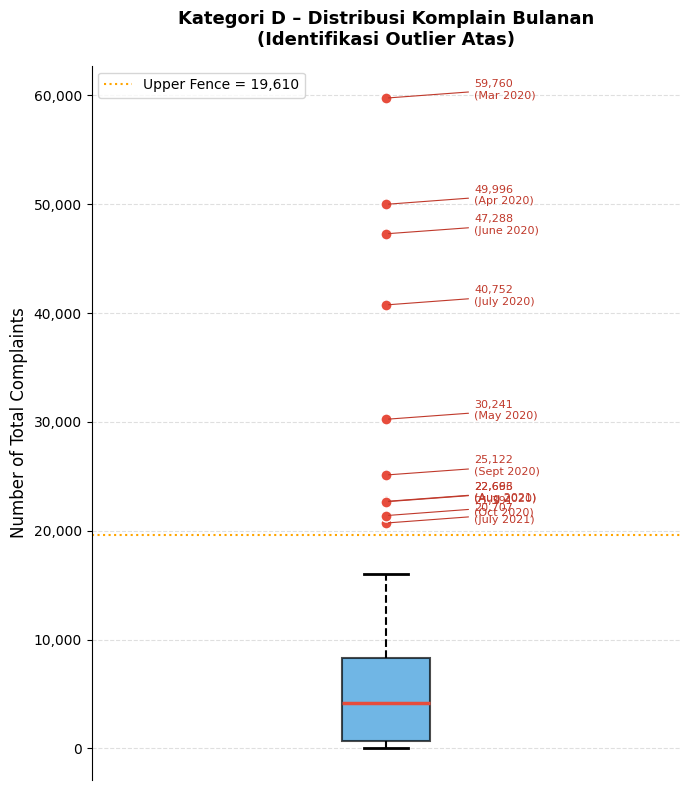

In [10]:
complaints = df["Number of Total Complaints"].dropna()
Q1 = complaints.quantile(0.25)
Q3 = complaints.quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
outliers = complaints[complaints > upper_fence]

print(f"Q1 = {Q1:,.0f} | Q3 = {Q3:,.0f} | IQR = {IQR:,.0f}")
print(f"Upper Fence = {upper_fence:,.0f}")
print(f"Jumlah bulan outlier atas: {len(outliers)}")

fig4, ax4 = plt.subplots(figsize=(7, 8))
ax4.boxplot(complaints, vert=True, patch_artist=True,
            boxprops=dict(facecolor="#3498db", alpha=0.7, linewidth=1.5),
            medianprops=dict(color="#e74c3c", linewidth=2.5),
            whiskerprops=dict(linewidth=1.5, linestyle="--"),
            capprops=dict(linewidth=2),
            flierprops=dict(marker="o", markerfacecolor="#e74c3c", markersize=8,
                            markeredgecolor="white", markeredgewidth=1))

ax4.axhline(upper_fence, color="orange", linewidth=1.5, linestyle=":",
            label=f"Upper Fence = {upper_fence:,.0f}")

for val in outliers:
    month_label = df.loc[df["Number of Total Complaints"] == val, ["Year","Month"]].values
    label = f"{month_label[0][1]} {int(month_label[0][0])}" if len(month_label) > 0 else ""
    ax4.annotate(f"{val:,}\n({label})",
                 xy=(1, val), xytext=(1.15, val),
                 fontsize=8, color="#c0392b",
                 arrowprops=dict(arrowstyle="-", color="#c0392b", lw=0.8))

ax4.set_title("Kategori D – Distribusi Komplain Bulanan\n(Identifikasi Outlier Atas)", fontsize=13, fontweight="bold", pad=15)
ax4.set_ylabel("Number of Total Complaints", fontsize=12)
ax4.set_xticks([])
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax4.legend(fontsize=10)
ax4.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine(ax=ax4, top=True, right=True, bottom=True)
plt.tight_layout()
plt.show()

## Grafik 5 – Gabungan (2×2 Grid)
Kombinasi keempat grafik menggunakan `plt.subplots(2, 2)` dengan pendekatan objek `ax=axes[x, y]`

In [ ]:
fig5, axes = plt.subplots(2, 2, figsize=(18, 12))
fig5.suptitle("Analisis Data Call Report – Kelas G", fontsize=16, fontweight="bold", y=0.98)

# ── Subplot [0,0] – Kategori A ──
ax = axes[0, 0]
bars = ax.bar(agg_year["Year"].astype(str), agg_year["Total Number of Calls"],
              color=sns.color_palette("Blues_d", len(agg_year)), edgecolor="white")
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 30000, f"{h/1e6:.2f}M",
            ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_title("A – Total Panggilan per Tahun", fontsize=12, fontweight="bold")
ax.set_xlabel("Tahun"); ax.set_ylabel("Total Calls")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x:,.0f}"))
ax.set_ylim(0, agg_year["Total Number of Calls"].max() * 1.18)
ax.grid(axis="y", linestyle="--", alpha=0.4); sns.despine(ax=ax, top=True, right=True)

# ── Subplot [0,1] – Kategori B ──
ax = axes[0, 1]
ax.plot(df_2024["Month"].astype(str), df_2024["Number of Total Complaints"],
        marker="o", color="#e74c3c", linewidth=2.5, markersize=7,
        markerfacecolor="white", markeredgewidth=2)
for _, row in df_2024.iterrows():
    ax.annotate(f"{row['Number of Total Complaints']:,}",
                xy=(row["Month"], row["Number of Total Complaints"]),
                xytext=(0, 10), textcoords="offset points", ha="center", fontsize=8, color="#c0392b")
ax.set_title("B – Tren Bulanan Komplain 2024", fontsize=12, fontweight="bold")
ax.set_xlabel("Bulan"); ax.set_ylabel("Total Complaints")
ax.set_ylim(0, df_2024["Number of Total Complaints"].max() * 1.25)
ax.grid(linestyle="--", alpha=0.35); sns.despine(ax=ax, top=True, right=True)

# ── Subplot [1,0] – Kategori C ──
ax = axes[1, 0]
sc = ax.scatter(df["Total Number of Doctors Consultancy"], df["Total Number of Calls"],
                c=df["Year"], cmap="viridis", s=50, alpha=0.75, edgecolor="white", linewidth=0.4)
ax.plot(x_line, m * x_line + b, color="#e74c3c", linewidth=2, linestyle="--")
ax.text(0.05, 0.92, f"r = {r:.4f}", transform=ax.transAxes, fontsize=11,
        color="#c0392b", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#c0392b", alpha=0.8))
plt.colorbar(sc, ax=ax, label="Tahun", shrink=0.9)
ax.set_title("C – Korelasi Konsultasi Dokter vs Total Panggilan", fontsize=12, fontweight="bold")
ax.set_xlabel("Doctors Consultancy"); ax.set_ylabel("Total Calls")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x:,.0f}"))
ax.grid(linestyle="--", alpha=0.3); sns.despine(ax=ax, top=True, right=True)

# ── Subplot [1,1] – Kategori D ──
ax = axes[1, 1]
ax.boxplot(complaints, vert=True, patch_artist=True,
           boxprops=dict(facecolor="#3498db", alpha=0.7, linewidth=1.5),
           medianprops=dict(color="#e74c3c", linewidth=2.5),
           whiskerprops=dict(linewidth=1.5, linestyle="--"),
           capprops=dict(linewidth=2),
           flierprops=dict(marker="o", markerfacecolor="#e74c3c", markersize=7,
                           markeredgecolor="white", markeredgewidth=1))
ax.axhline(upper_fence, color="orange", linewidth=1.5, linestyle=":",
           label=f"Upper Fence\n{upper_fence:,.0f}")
ax.set_title("D – Distribusi Komplain (Outlier Atas)", fontsize=12, fontweight="bold")
ax.set_ylabel("Total Complaints"); ax.set_xticks([])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(fontsize=9); ax.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine(ax=ax, top=True, right=True, bottom=True)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()